<a href="https://colab.research.google.com/github/LaerteKimura/FIAP_trabalho_ML_Diagnostico/blob/main/FIAP_trabalho_ML_Diagnostico.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **POSTECH - IA para Devs - Tech Challenge - Fase 1**

**GRUPO 63**

*   Felipe Demétrius Martins da Silva - RM 367962
*   Kauê Bove Martins - RM 367999
*   Laerte Kimura - RM 368091
*   Thiago Albuquerque Rosa - RM 366838
*   Vinicius Otavio Soares da Silva - RM 367861

**DATASET**

Para o presente trabalho, o grupo escolheu um dos datasets sugeridos no próprio enunciado do Tech Challenge: o [Diabetes Data Set](https://www.kaggle.com/datasets/mathchi/diabetes-data-set/data), disponível no Kaggle (autor: mathchi).

Esse conjunto de dados foi originalmente coletado pelo National Institute of Diabetes and Digestive and Kidney Diseases e contém 768 registros de pacientes, com informações clínicas e fisiológicas relacionadas ao diagnóstico de diabetes tipo 2.

O objetivo principal é prever se um paciente tem ou não diabetes, a partir de medidas coletadas em exames de rotina.
A variável alvo é `Outcome`, que assume valor 1 para pacientes com diagnóstico positivo e 0 para negativos.


**Atributos do dataset**

O conjunto de dados contém 8 atributos de entrada e 1 atributo alvo (`Outcome`):

| Coluna                       | Descrição                                                           |
| :--------------------------- | :------------------------------------------------------------------ |
| **Pregnancies**              | Número de vezes que a paciente ficou grávida.                       |
| **Glucose**                  | Nível de glicose no sangue após teste oral de tolerância à glicose. |
| **BloodPressure**            | Pressão arterial diastólica (em mm Hg).                             |
| **SkinThickness**            | Espessura da dobra cutânea do tríceps (em mm).                      |
| **Insulin**                  | Nível de insulina sérica em jejum (mu U/ml).                        |
| **BMI**                      | Índice de massa corporal (peso em kg dividido pela altura em m²).   |
| **DiabetesPedigreeFunction** | Mede a predisposição genética para diabetes.                        |
| **Age**                      | Idade da paciente (em anos).                                        |
| **Outcome**                  | Variável alvo (0 = não possui diabetes, 1 = possui diabetes).       |


Importando as bibliotecas necessárias para o projeto

In [20]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve, auc, accuracy_score
from sklearn import metrics

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


Definindo funções auxiliares para apoiar a análise

In [21]:
def plotHistogram(values, label, feature, title):
    sns.set_style("whitegrid")
    plotOne = sns.FacetGrid(values, hue=label, aspect=2)
    plotOne.map(sns.histplot, feature, kde=False)
    plotOne.set(xlim=(0, values[feature].max()))
    plotOne.add_legend()
    plotOne.set_axis_labels(feature, 'Proportion')
    plotOne.fig.suptitle(title)
    plt.show()

def plot_knn_error_rates(X_train_scaled, X_test_scaled, Y_train, Y_test, k_range, title):
    """
    Calculates and plots the error rate for different K values in KNN.

    Args:
        X_train_scaled: Scaled training features.
        X_test_scaled: Scaled test features.
        Y_train: Training target.
        Y_test: Test target.
        k_range: A range of K values to test.
        title: The title for the plot.
    """
    error_rates = []
    for i in k_range:
        knn = KNeighborsClassifier(n_neighbors=i)
        knn.fit(X_train_scaled, Y_train)
        pred_i = knn.predict(X_test_scaled)
        error_rates.append(np.mean(pred_i != Y_test))

    plt.figure(figsize=(12, 6))
    plt.plot(k_range, error_rates, color='red', linestyle='dashed', marker='o',
             markerfacecolor='blue', markersize=10)
    plt.title(title)
    plt.xlabel('K Value')
    plt.ylabel('Mean Error')
    plt.show()

Importando o dataset a partir do mesmo diretório

In [42]:
data = pd.read_csv("diabetes_dataset.csv")

Verificando a importação dos dados na variável data, exibindo as primeiras linhas e checando as principais informações do dataset


In [23]:
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [24]:
data.shape

(768, 9)

In [25]:
data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


Verificando a informação do dataset e os datatypes das colunas

In [26]:
data.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


Analisando a distribuição dos dados em relação à variável alvo (`Outcome`)

In [27]:
data.groupby("Outcome").describe()

Pregnancies                                                Glucose  \
              count      mean       std  min   25%  50%  75%   max   count   
Outcome                                                                      
0             500.0  3.298000  3.017185  0.0  1.00  2.0  5.0  13.0   500.0   
1             268.0  4.865672  3.741239  0.0  1.75  4.0  8.0  17.0   268.0   

                     ... DiabetesPedigreeFunction           Age             \
               mean  ...                      75%    max  count       mean   
Outcome              ...                                                     
0        109.980000  ...                  0.56175  2.329  500.0  31.190000   
1        141.257463  ...                  0.72800  2.420  268.0  37.067164   

                                                  
               std   min   25%   50%   75%   max  
Outcome                                           
0        11.667655  21.0  23.0  27.0  37.0  81.0  
1        10.968254  21.0  28.0  36.0  44.0  70.0  

[2 rows x 64 columns]

Nosso modelo possui aproximadamente 65% de pacientes com diabetes e 35% de pacientes com diabetes, o que quer dizer que se o modelo prever "0" na variável Outcome, ele já tem 65% de acurácia, mesmo sem detectar ninguem com diabetes.

Como estamos trabalhando com o sistema de saúde, errar o diagnóstico significa classificar pessoas saudáveis como doentes, ou pior, classificar pessoas doentes, que precisam de tratamento, como saudáveis. Por este motivo, o grupo analisou as opções abaixo para tratar o desbalanceamento.

1.   Aumento da classe minoritária (`Oversampling`): teríamos que replicar os registros da classe com menos exemplos ou inventar novos exemplos, mas isso poderia criar ruídos e atrapalhar nosso processo, por isso ele não será usado.
2.   Redução da classe majoritária (`Undersampling`): teríamos que remover exemplos da clase mais frequente, mas como nosso dataset é relativamente pequeno, pode eliminar informações úteis, por isso não a usaremos.
3.   Ajuste de pesos das classes (`class_weight`): usar esta estratégia nos fará dar mais importância à classe minoritária. Desta forma, não precisamos alterar o número de amostrar. Por este motivo, escolhemos essa estratégia.
4.   Ajuste de métricas de avaliação: Não poderemos olhar apenas para a acurácia por causa do desbalanceamento, por isso será fundamental avaliar o modelo com métricas adequadas, como Recall, F1-Score e AUC-ROC, mas falaremos mais disso mais tarde.



**Análise de correlação dos dados**
Analisando a correlação dos dados para entender quais têm maior relação com o diagnóstico de diabetes (`Outcome`).

<Axes: >

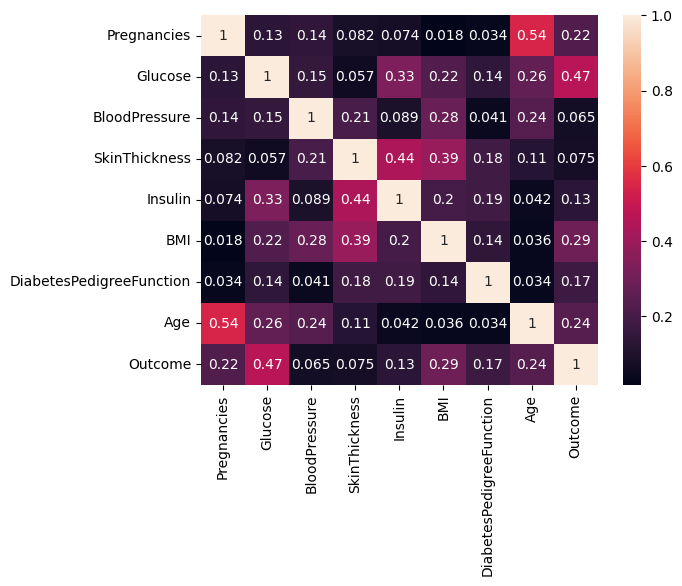

In [29]:
sns.heatmap(data.corr().abs(),annot=True)

In [44]:
data.corr(numeric_only=True)['Outcome'].abs().sort_values(ascending=False)

,Outcome
Outcome,1.000000
Glucose,0.466581
BMI,0.292695
Age,0.238356
Pregnancies,0.221898
DiabetesPedigreeFunction,0.173844
Insulin,0.130548
SkinThickness,0.074752
BloodPressure,0.065068


**Tratamento de dados faltantes**

Verificamos que as variáveis Glicosem IMC, Idade e Quantidade de gravidês apresentam maiores coeficientes de correlação com `Outcome`, o que sugere que são mais importantes para a construção do modelo de predição.

Verificando a quantidade de valores nulos por coluna

In [30]:
print("Quantidade de valores nulos por coluna:")
data.isna().sum()

Quantidade de valores nulos por coluna:


,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


Não há valores nulos.

Verificando a quantidade de colunas com valor igual a zero.

In [31]:
print("Quantidade de valores zero por coluna:")
(data == 0).sum()

Quantidade de valores zero por coluna:


,0
Pregnancies,111
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11
DiabetesPedigreeFunction,0
Age,0
Outcome,500


Filtrando colunas que tem a menos um valor igual a zero.

In [32]:
zero_columns = (data == 0).sum()
columns_with_zeros = zero_columns[zero_columns > 0]
print("\nColunas com valores zero:")
zero_columns[zero_columns > 0]


Colunas com valores zero:


,0
Pregnancies,111
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11
Outcome,500


Para as variáveis fisiológicas (`Glucose`,`BloodPressure`,`SkinThickness`,`Insulim`, `BMI`) não faz sentido que possuam valor zero. Isso quer dizer que quando forem zero vamos tratar como valores faltantes. Esses valores faltantes podem confundir os algorítmos, principalmente os sensíveis à escala, como Regressão Logística, KNN e SVM e. Por este motivo, vamos atribuir valor NaN e depois inputar o valor da mediana por coluna.

Primeiro atribuímos NaN para as variáveis faltantes.

In [33]:
cols_invalid_zero = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI", "Age"]
data[cols_invalid_zero] = data[cols_invalid_zero].replace(0, np.nan)

Depois criamos novas colunas com o nome das variáveis que tem dados faltantes + "_was_measured", para indicar ao modelo as colunas onde a variável não foi medida.

In [34]:
for c in ["Glucose","BloodPressure","SkinThickness","Insulin","BMI"]:
    data[f"{c}_was_measured"] = (~data[c].isna()).astype(int)

Agora inputamos o valor da mediana nos valores NaN e conferimos se sobrou alguma variável com dados faltantes.

In [35]:
medianas = data[cols_invalid_zero].median()
data[cols_invalid_zero] = data[cols_invalid_zero].fillna(medianas)

print("\nValores ausentes após imputação (devem ser 0):")
display(data[cols_invalid_zero].isna().sum())


Valores ausentes após imputação (devem ser 0):


,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
Age,0


In [36]:
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,Glucose_was_measured,BloodPressure_was_measured,SkinThickness_was_measured,Insulin_was_measured,BMI_was_measured
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50,1,1,1,1,0,1
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31,0,1,1,1,0,1
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32,1,1,1,0,0,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0,1,1,1,1,1
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1,1,1,1,1,1


**Análise e tratamento de outliers**

Após o tratamento dos valores ausentes, analisamos a presença de outliers nas variáveis numéricas.
Esses valores podem representar erros de medição ou casos clínicos atípicos.
Utilizamos o método do Intervalo Interquartílico (IQR) para identificar observações fora do intervalo esperado.

In [40]:
# Método estatístico simples: IQR (Interquartile Range)
Q1 = data.quantile(0.25)
Q3 = data.quantile(0.75)
IQR = Q3 - Q1

# Limites para detecção
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Verificando quais colunas têm outliers
outliers = ((data < lower_bound) | (data > upper_bound)).sum()
display(outliers)


,0
Pregnancies,4
Glucose,0
BloodPressure,14
SkinThickness,87
Insulin,346
BMI,8
DiabetesPedigreeFunction,29
Age,9
Outcome,0
Glucose_was_measured,5


<Axes: >

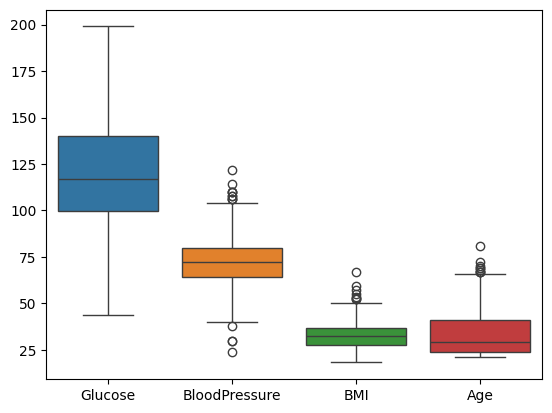

In [41]:
sns.boxplot(data=data[['Glucose','BloodPressure','BMI','Age']])

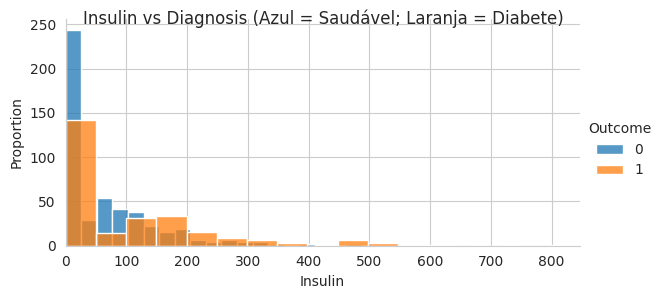

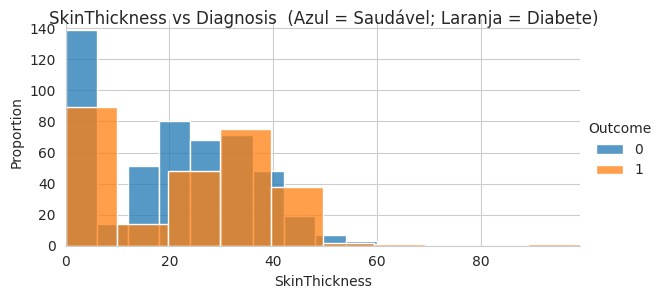

In [ ]:
plotHistogram(data,"Outcome",'Insulin','Insulin vs Diagnosis (Azul = Saudável; Laranja = Diabete)')
plotHistogram(data,"Outcome",'SkinThickness','SkinThickness vs Diagnosis  (Azul = Saudável; Laranja = Diabete)')

Podemos desconsiderar o Outcome pois representa nossa variável target.
Insulin tem uma considerável quantidade de linhas zeradas assim como a coluna SkinThickness. Analisar qual a correlação dessas colunas para com nossa target (Outcome), a fim de validarmos a necessidade de um preenchimento ou exclusão dessas colunas

In [ ]:
data.corr()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.129459,0.141282,-0.081672,-0.073535,0.017683,-0.033523,0.544341,0.221898
Glucose,0.129459,1.000000,0.152590,0.057328,0.331357,0.221071,0.137337,0.263514,0.466581
BloodPressure,0.141282,0.152590,1.000000,0.207371,0.088933,0.281805,0.041265,0.239528,0.065068
SkinThickness,-0.081672,0.057328,0.207371,1.000000,0.436783,0.392573,0.183928,-0.113970,0.074752
Insulin,-0.073535,0.331357,0.088933,0.436783,1.000000,0.197859,0.185071,-0.042163,0.130548
BMI,0.017683,0.221071,0.281805,0.392573,0.197859,1.000000,0.140647,0.036242,0.292695
DiabetesPedigreeFunction,-0.033523,0.137337,0.041265,0.183928,0.185071,0.140647,1.000000,0.033561,0.173844
Age,0.544341,0.263514,0.239528,-0.113970,-0.042163,0.036242,0.033561,1.000000,0.238356
Outcome,0.221898,0.466581,0.065068,0.074752,0.130548,0.292695,0.173844,0.238356,1.000000


A coluna Insulin e SkinThickness não se mostram com alta correlação com a variável target.

Para facilitar a identificação dos nomes das colunas, pedi pra listar

In [ ]:
data.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

Plotando as distribuições para identificar valores "Outliners" - pode se verificar que foi encontrado ocorrências na Coluna "Insulin" , "Blood Pressure" , "BMI" ...

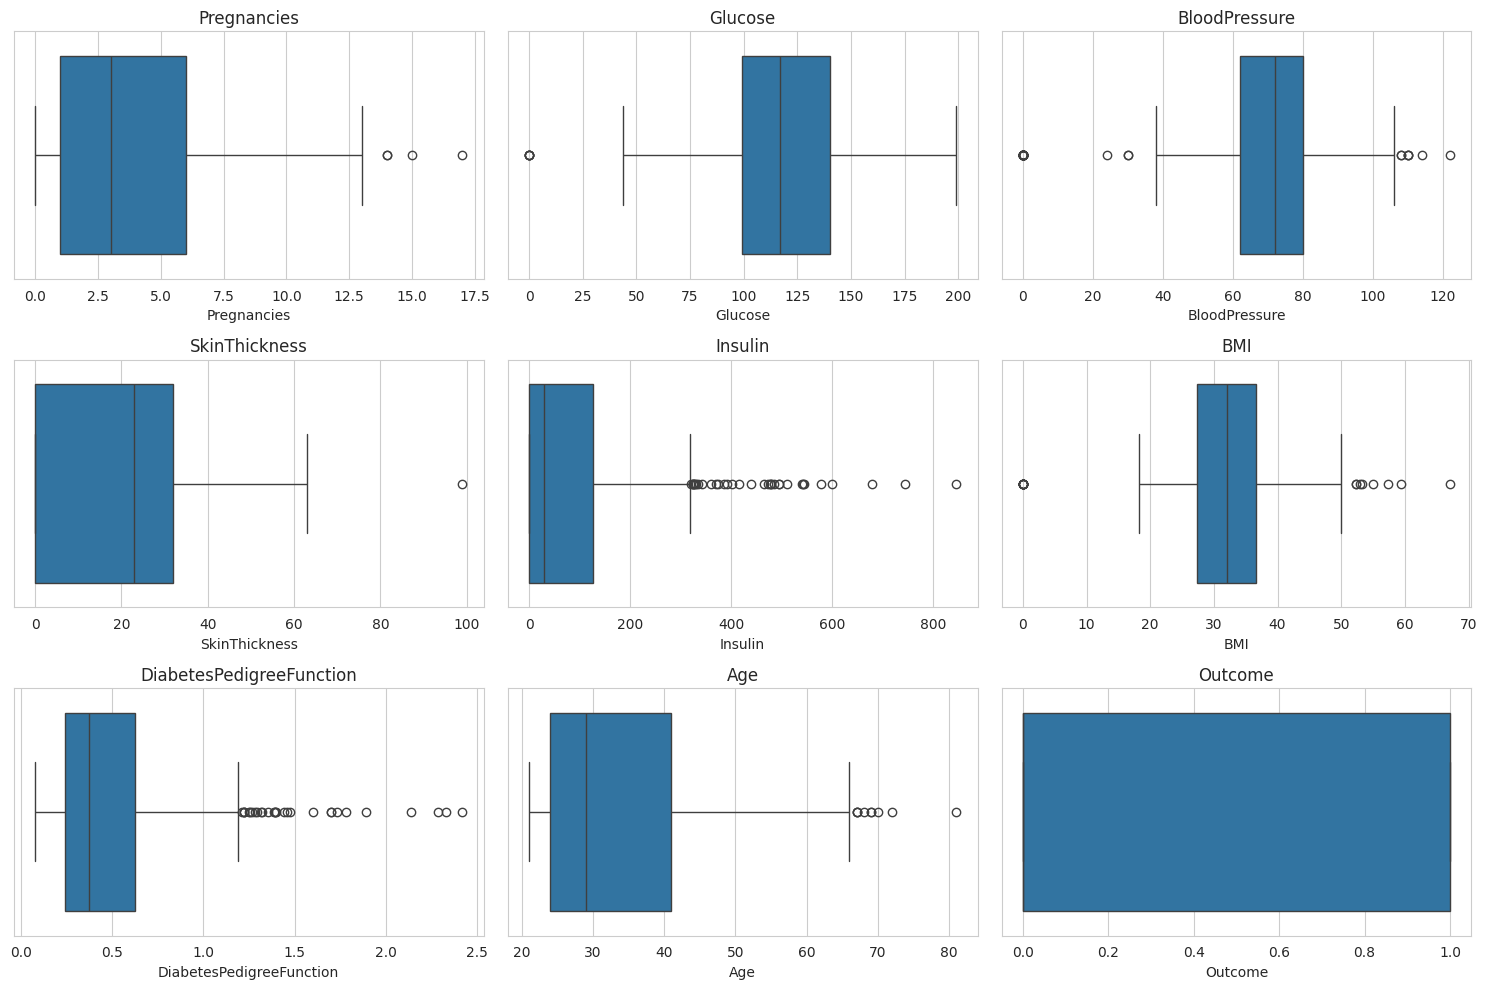

In [ ]:

numerical_cols = data.select_dtypes(include=['int64', 'float64']).columns

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(3, 3, i + 1)
    sns.boxplot(x=data[col])
    plt.title(col)

plt.tight_layout()
plt.show()

Removendo os Outliners e criando um novo dataset = **datacleaned**

In [ ]:
# Function to remove outliers
def remove_outliers_iqr(df):
    Q1 = df.quantile(0.25)
    Q3 = df.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df_cleaned = df[~((df < lower_bound) | (df > upper_bound)).any(axis=1)]
    return df_cleaned


data_cleaned = remove_outliers_iqr(data[numerical_cols])

print("Shape Original :", data.shape)
print("Shape depois de remover outliers:", data_cleaned.shape)

Shape Original : (768, 9)
Shape depois de remover outliers: (639, 9)


Verificamos novamente os gráficos para conferencia que os outliners foram removidos com sucesso

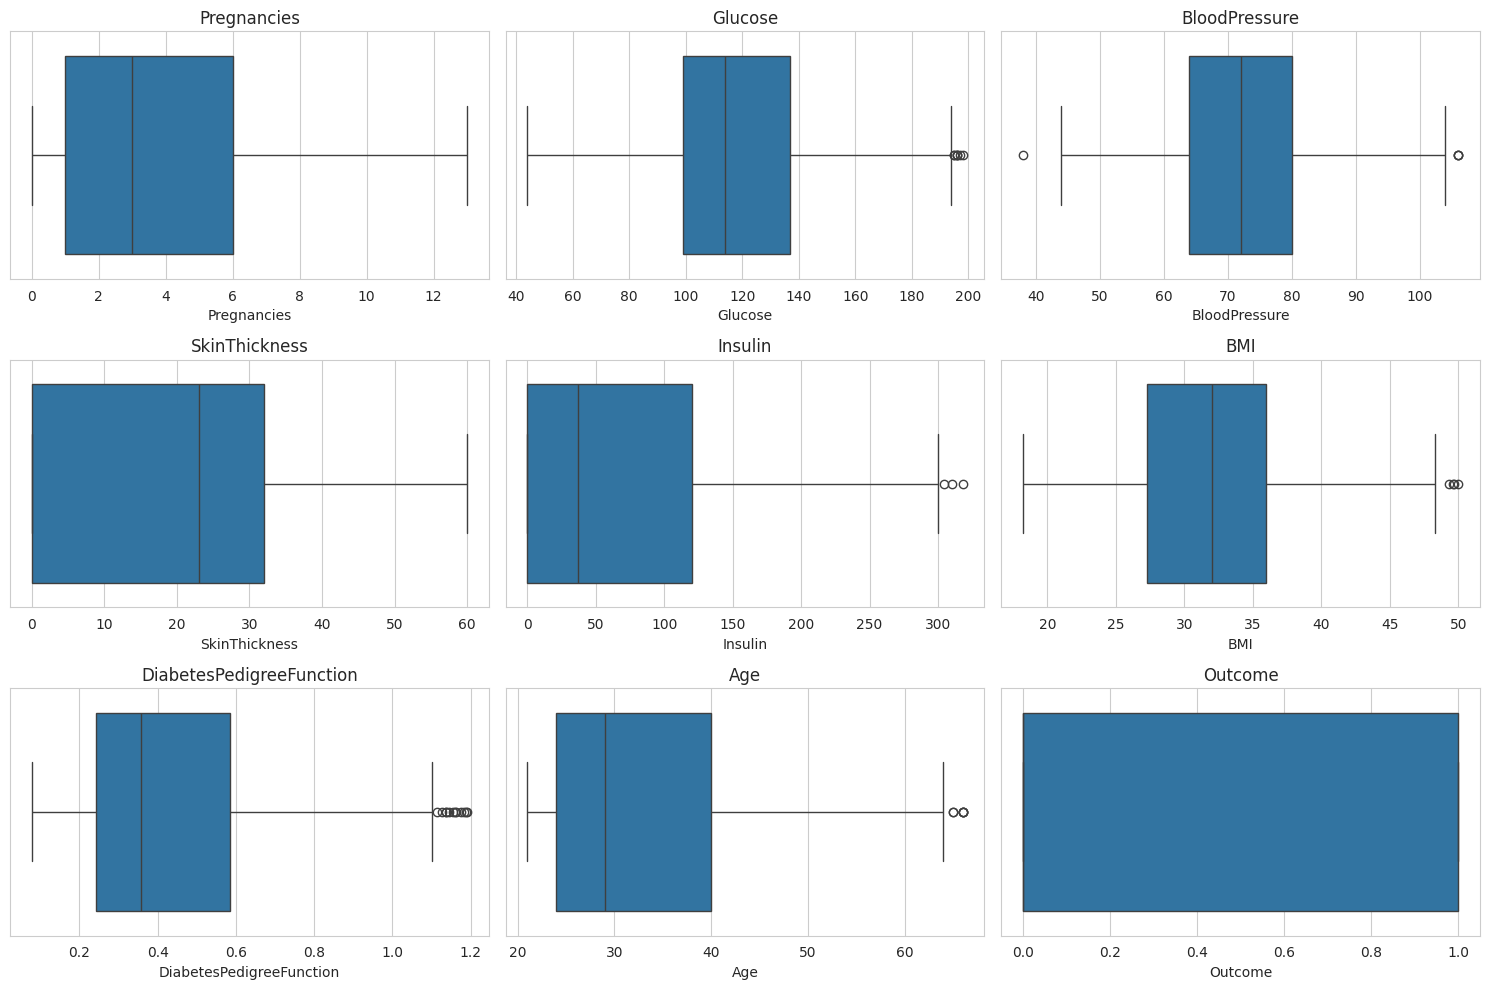

In [ ]:
numerical_cols = data_cleaned.select_dtypes(include=['int64', 'float64']).columns

# Create box plots for each numerical column
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(3, 3, i + 1)
    sns.boxplot(x=data_cleaned[col])
    plt.title(col)

plt.tight_layout()
plt.show()

Iniciando a separacao da lista de variaveis de entrada e lista de variaveis target

In [ ]:
x= data_cleaned[['Pregnancies', 'Glucose', 'BloodPressure', 'BMI', 'DiabetesPedigreeFunction', 'Age']]

In [ ]:
y= data_cleaned['Outcome']

Verificando a separação das variaveis x e y

In [ ]:
x

,Pregnancies,Glucose,BloodPressure,BMI,DiabetesPedigreeFunction,Age
0,6,148,72,33.6,0.627,50
1,1,85,66,26.6,0.351,31
2,8,183,64,23.3,0.672,32
3,1,89,66,28.1,0.167,21
5,5,116,74,25.6,0.201,30
...,...,...,...,...,...,...
763,10,101,76,32.9,0.171,63
764,2,122,70,36.8,0.340,27
765,5,121,72,26.2,0.245,30
766,1,126,60,30.1,0.349,47


In [ ]:
y

,Outcome
0,1
1,0
2,1
3,0
5,0
...,...
763,0
764,0
765,0
766,1


Executando algoritmo para encontrar o melhor numero "vizinho" para o KNN

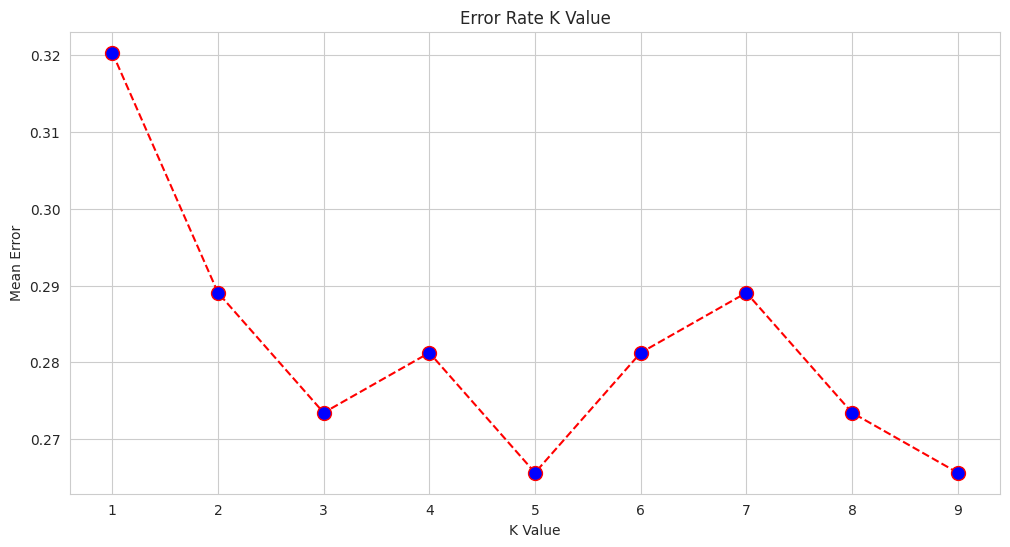

In [ ]:
plot_knn_error_rates(X_train_scaled=X_train, X_test_scaled=X_test, Y_train=Y_train, Y_test=Y_test, k_range=range(1, 10), title='Error Rate K Value')

Encontrado o valor 5 e 9 como melhores valores para o numero vizinho de KNN, vamos utilizar o 5.
Executando o treinamento com 80% dos dados para aprendizagem e 20% para teste

In [ ]:
X_train,X_test,Y_train,Y_test = train_test_split(x , y , test_size=0.20, stratify=y,random_state=42)

In [ ]:
classifier_model = KNeighborsClassifier(n_neighbors=5)

In [ ]:
classifier_model.fit(X_train,Y_train)

KNeighborsClassifier()

In [ ]:
classifier_model.predict([[1, 148,	72,	33.6,	0.627,	50]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


array([1])

In [ ]:
y_predito = classifier_model.predict(X_test)

In [ ]:
accuracy_score(y_true= Y_test , y_pred = y_predito)

0.734375

Acuracia encontrada de 73% utilizando KNN , vamos tentar criar uma escala padronizada a fim de verificar a efetividade

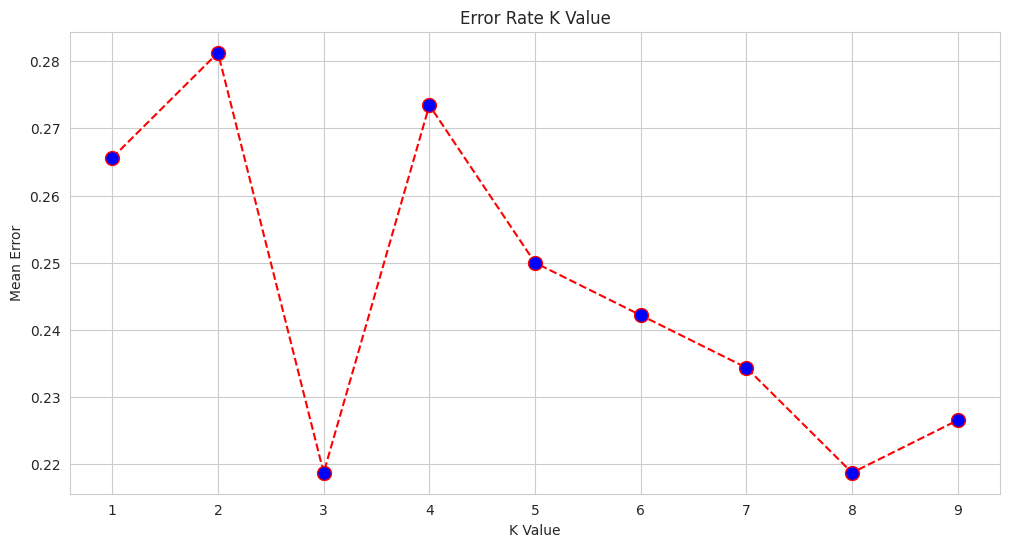

In [ ]:
scaler = StandardScaler()

scaler.fit(X_train)

x_train_escalonado = scaler.transform(X_train)
x_test_escalonado = scaler.transform(X_test)


plot_knn_error_rates(X_train_scaled=x_train_escalonado, X_test_scaled=x_test_escalonado, Y_train=Y_train, Y_test=Y_test, k_range=range(1, 10), title='Error Rate K Value')

In [ ]:
classifier_model = KNeighborsClassifier(n_neighbors=3)
classifier_model.fit(x_train_escalonado, Y_train)

KNeighborsClassifier(n_neighbors=3)

In [ ]:
y_predito = classifier_model.predict(x_test_escalonado)
print(accuracy_score(Y_test, y_predito))

0.78125


Tivemos aumento de para 78% ao criar uma escala padronizada para os valores



---



Iniciando testes com SVM

In [ ]:

scaler = StandardScaler()


scaler.fit(X_train)

x_train_escalonado = scaler.transform(X_train)
x_test_escalonado = scaler.transform(X_test)


from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC

svm = Pipeline([
    ("linear_svc", LinearSVC(C=1))
])

svm.fit(x_train_escalonado, Y_train)

Pipeline(steps=[('linear_svc', LinearSVC(C=1))])


y_predito_svm = svm.predict(x_test_escalonado)

print(accuracy_score(Y_test, y_predito_svm))


0.7734375


Com o modelo de SVM a acuracia foi 77%



---
Aqui em diante é um teste



In [ ]:
y_prob = classifier_model.predict_proba(X_test)[:,1]

In [ ]:
scaler = StandardScaler()


scaler.fit(X_train)

x_train_escalonado = scaler.transform(X_train)
x_test_escalonado = scaler.transform(X_test)

              precision    recall  f1-score   support

           0       0.77      0.86      0.81        88
           1       0.59      0.42      0.49        40

    accuracy                           0.73       128
   macro avg       0.68      0.64      0.65       128
weighted avg       0.71      0.73      0.71       128

              precision    recall  f1-score   support

           0       0.80      0.89      0.84        88
           1       0.68      0.53      0.59        40

    accuracy                           0.77       128
   macro avg       0.74      0.71      0.72       128
weighted avg       0.76      0.77      0.76       128

0.7734375


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


<Figure size 1500x500 with 0 Axes>

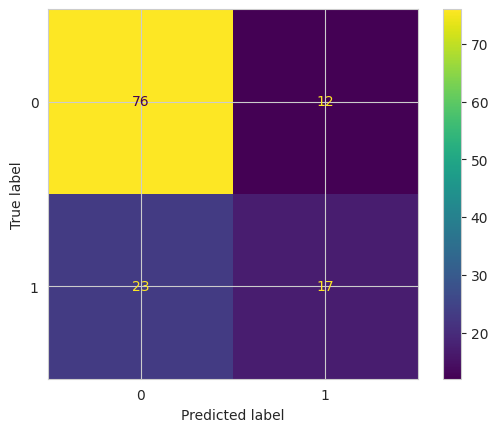

<Figure size 1500x500 with 0 Axes>

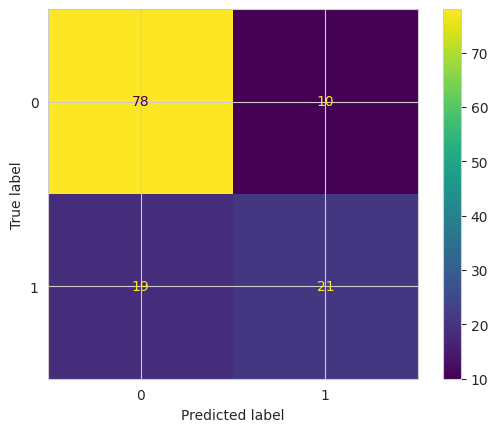

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay # matriz de confusão
from sklearn.metrics import classification_report
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve, auc

matriz_confusao = confusion_matrix(y_true = Y_test,    #dados reais
                                   y_pred = y_predito #dados predito
                                   )
# plotando uma figura com a matriz de confusao
figure = plt.figure(figsize=(15, 5))

disp = ConfusionMatrixDisplay(confusion_matrix = matriz_confusao)

disp.plot(values_format='d')

# Metricas de precisão, revocação, f1-score e acurácia.
print(classification_report(Y_test, y_predito)) #relatório de validação das métrica de desempenho.

# Metricas de precisão, revocação, f1-score e acurácia.
print(classification_report(Y_test, y_predito_svm)) #relatório de validação das métrica de desempenho.


svm = Pipeline([
    ("linear_svc", LinearSVC(C=1))
])

svm.fit(x_train_escalonado, Y_train)

Pipeline(steps=[('linear_svc', LinearSVC(C=1))])

y_predito_svm = svm.predict(x_test_escalonado)

matriz_confusao_svm = confusion_matrix(y_true = Y_test,       #dados reais
                                   y_pred = y_predito_svm #dados predito
                                   )

# plotando uma figura com a matriz de confusao
figure = plt.figure(figsize=(15, 5))

disp = ConfusionMatrixDisplay(confusion_matrix = matriz_confusao_svm)

disp.plot(values_format='d')

y_prob = classifier_model.predict_proba(x_test_escalonado)[:,1]

false_positive_rate, true_positive_rate, thresholds = roc_curve(Y_test, y_prob)
roc_auc = auc(false_positive_rate, true_positive_rate)
roc_auc


print(accuracy_score(Y_test, y_predito_svm))

Text(0.5, 0, 'False Positive Rate')

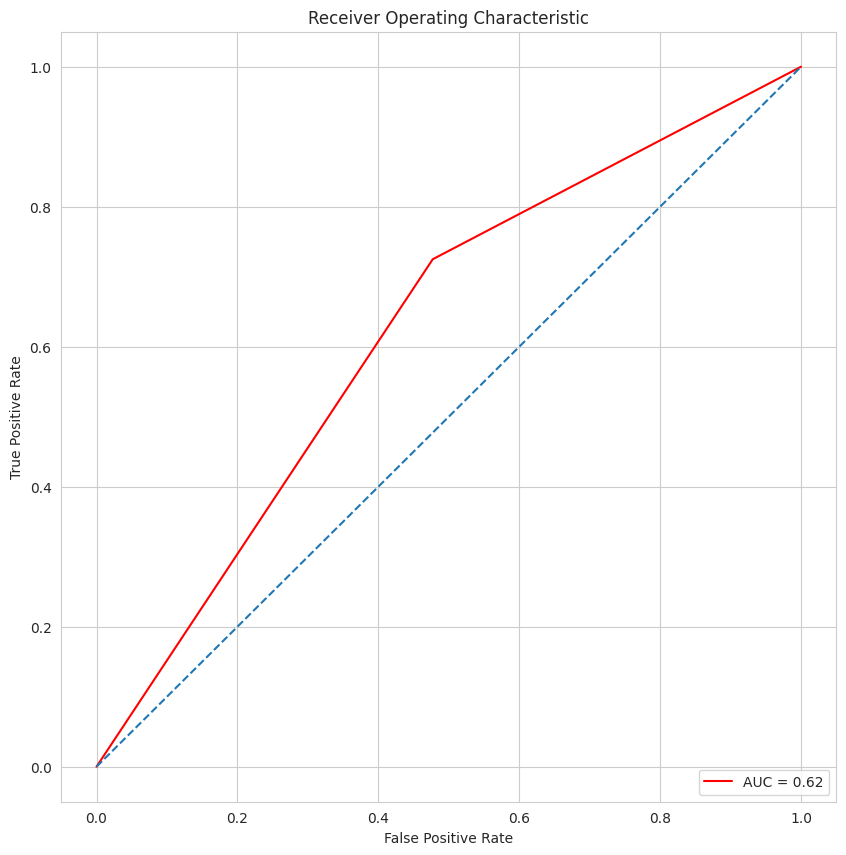

In [ ]:

import matplotlib.pyplot as plt

plt.figure(figsize=(10,10))
plt.title('Receiver Operating Characteristic')
plt.plot(false_positive_rate,true_positive_rate, color='red',label = 'AUC = %0.2f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],linestyle='--')
plt.axis('tight')
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')